(05-32-intermediaries)=

# 2008 en intermediary asset pricing

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 2007–2017, van de run op de repomarkt tot de kapitaalratio van de primary
dealers als risicofactor.

**Wat we al weten.** Elk prijsmodel is een uitspraak over de stochastic discount factor,
en elke factor is een kandidaat voor $m_{t+1}$ ([](#05-26-sdf-unificatie)). De
[vorige lecture](#05-31-portfolio-choice) liet zien hoe een belegger die de
schattingsfout in gemiddelden serieus neemt, zijn portefeuille kiest. Uit
[LTCM](#04-22-risk-management), [limits of arbitrage](#04-23-behavioral) en
[liquiditeit](#04-24-microstructuur) weten we dat een gehefboomde arbitrageur kan
omvallen voordat zijn gelijk uitbetaalt, en dat liquiditeit verdwijnt wanneer iedereen haar
nodig heeft. Wat ontbrak, was de stap van één fonds naar de prijzen van alle activa.

**Welke vraag staat open.** Als de marginale belegger geen huishouden is maar een
gefinancierde tussenpersoon, prijst diens balans dan de verwachte rendementen, en waarom
explodeerden de risicopremies in 2008?
```

## Overzicht

In de herfst van 2008 gebeurde wat de consumptiemodellen van [](#03-12-consumptie-capm)
niet kunnen beschrijven. De consumptie van huishoudens daalde matig, maar credit- en
financieringsspreads schoten omhoog en obligaties met identieke kasstromen kregen
verschillende prijzen. De verliezen zaten bij de dealers en banken die de markten maakten en
hun posities kortlopend financierden. Santa-Clara vat de verschuiving
samen: "What the crisis changed was the field's idea of who the marginal investor is. The
representative consumer of Lucas and Breeden holds the whole market and prices it off his
consumption; the models that fit the crisis put a leveraged intermediary in his place, whose
balance-sheet capacity is the state variable" {cite}`SantaClara2026`.

De theorie lag deels klaar. {cite:t}`ShleiferVishny1997` en {cite:t}`GrombVayanos2002`
hadden arbitrageurs met beperkt kapitaal gemodelleerd; {cite:t}`BrunnermeierPedersen2009`
lieten zien dat marktliquiditeit en financieringsliquiditeit elkaar versterken;
{cite:t}`GarleanuPedersen2011` maakten van marges een prijsbepalende grootheid. Daarna
kwam de empirie. {cite:t}`AdrianShin2010` documenteerden dat de leverage van broker-dealers
procyclisch is, {cite:t}`HeKrishnamurthy2013` bouwden een evenwichtsmodel waarin de
kapitaalratio van de intermediair de toestandsvariabele is, en
{cite:t}`AdrianEtulaMuir2014` en {cite:t}`HeKellyManela2017` maakten van de balans van de
intermediair een factor in de cross-sectie. Dat laatste werk definieert het tijdvak: het
bracht de theorie-met-tests terug (motief 3), met een voorspelling over het *teken* van de
prijs van risico, en het leverde twee factoren op met tegengestelde tekens die allebei
significant heetten.

Na een handberekening, de spiraal van Brunnermeier en Pedersen, een vereenvoudigd
He-Krishnamurthy-model en drie simulaties repliceren we de kapitaalratio en de
cross-sectionele toets van {cite:t}`HeKellyManela2017`, de broker-dealer-leverage van
{cite:t}`AdrianEtulaMuir2014` uit de Flow of Funds, en de voorspellende kracht van de
kapitaalratio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Een dealerbank koopt obligaties met een klein beetje eigen geld en veel geleend geld. De
geldgever eist onderpand en houdt een *haircut* in (het deel van de waarde dat de bank met
eigen vermogen moet financieren). Bij een haircut van 10% mag de balans hoogstens tien keer
het eigen vermogen zijn. Zolang prijzen stabiel zijn, is dat een rustig bedrijf.

Daalt de prijs 2%, dan verliest een bank met hefboom tien een vijfde van haar eigen vermogen en
moet ze verkopen. Verkopen veel banken tegelijk, dan moeten kopers buiten de sector worden
verleid met een lagere prijs, en die lagere prijs is een nieuw verlies dat nieuwe verkopen
afdwingt: de *verliesspiraal*. Verhogen de geldgevers door de grotere koersschommelingen ook nog
hun haircuts, dan moet de balans krimpen zonder nieuw verlies: de *margespiraal*. Gorton en Metrick lieten zien dat het gemiddelde haircut op onderpand
anders dan staatsobligaties "rises from zero in early 2007 to nearly 50 percent at the peak
of the crisis in late 2008" (werkversie, p. 4) {cite}`GortonMetrick2012`.

Zo'n spiraal is niet-lineair: een kleine schok verdwijnt in de buffers, een grote wordt
versterkt. Er kunnen zelfs twee evenwichten zijn bij hetzelfde fundament: een liquide markt
waarin dealers de verkoopdruk opvangen, en een illiquide markt waarin de lage prijs hun
kapitaal al heeft opgegeten.

Als de dealer de marginale belegger is, is zijn marginale nut de stochastic discount factor.
Een euro is voor hem het meest waard als zijn kapitaal schaars is; een activum dat juist dan
slecht rendeert, moet gemiddeld meer opleveren. Omdat dealers in bijna elke markt handelen,
moet dezelfde prijs van dat risico in aandelen, obligaties en valuta terugkomen: een scherpe,
toetsbare voorspelling. Santa-Clara noemt het de nieuwe agenda van het decennium, met een
bekentenis erbij: "the equity premium may be less a fact about households' risk aversion than
about who is allowed to hold the risk" {cite}`SantaClara2026`.

## Toy-voorbeeld: één intermediair, één schok, twee rondes verkopen

Een intermediair heeft eigen vermogen $E = 10$ en activa $A = 100$ tegen prijs $p = 1$,
gefinancierd met schuld $90$. Zijn leverage is $L = A/E = 10$ en zijn kapitaalratio
$\eta = E/A = 10\%$. De geldgever eist $E \ge hA$ met haircut $h = 10\%$: de restrictie bindt
precies. Buiten de bankensector staan beleggers met vermogen $W = 1000$ en vraagelasticiteit
$\varepsilon = 2$: een verkoop ter waarde $S$ drukt de prijs met $S/(\varepsilon W) = S/2000$.

**Schok.** De fundamentele prijs daalt 2%. Het verlies is $0{,}02 \times 100 = 2$, dus
$E = 8$ en $A = 98$. De kapitaalratio is gedaald tot $8/98 = 8{,}16\%$ en de leverage gestegen
tot $12{,}25$.

**Eerste gedwongen verkoop.** Met $E = 8$ mag de balans hoogstens $8/0{,}10 = 80$ zijn, dus de
intermediair verkoopt $S_1 = 98 - 80 = 18$. De prijsimpact is $18/2000 = 0{,}9\%$, en die kost
op de resterende $80$ een verlies van $0{,}72$: $E = 7{,}28$, $A = 79{,}28$.

**Tweede ronde.** De toegestane balans is nu $72{,}8$, dus $S_2 = 79{,}28 - 72{,}8 = 6{,}48$,
met prijsimpact $0{,}324\%$ en een verlies van $72{,}8 \times 0{,}00324 = 0{,}236$. De
verkopen krimpen per ronde met ongeveer een factor $0{,}36$: elke euro verlies dwingt
$(1-h)/h = 9$ euro verkoop af, die $9/2000$ prijsdaling veroorzaakt op een balans van ongeveer
$80$, samen $80 \times 9/2000 = 0{,}36$. De reeks convergeert (de code rekent hem af) naar een
eigen vermogen van $6{,}94$ en een totale prijsdaling van $3{,}35\%$, waarvan $1{,}35$
procentpunt door de eigen verkopen komt. De kapitaalratio is na afloop weer $10\%$, maar bij
een eigen vermogen dat 31% lager is dan vóór de schok.

**Margespiraal.** Stel nu dat de geldgever na de schok het haircut verhoogt naar $12{,}5\%$
omdat de koersen beweeglijker zijn geworden. Dan mag de balans hoogstens $8/0{,}125 = 64$ zijn:
$S_1 = 34$, prijsimpact $1{,}7\%$, verlies $64 \times 0{,}017 = 1{,}088$, $E = 6{,}912$. In de
tweede ronde is de toegestane balans $55{,}30$ en de verkoop $62{,}91 - 55{,}30 = 7{,}62$.
Na convergentie is de prijs $4{,}12\%$ gedaald, is het eigen vermogen $6{,}65$ en de leverage
$8$.

Op het moment van de schok *daalt* de kapitaalratio (van 10% naar 8,16%); daarna *daalt* de
leverage door de gedwongen verkoop (van 10 naar 8 bij het hogere haircut). Dezelfde slechte
toestand geeft dus een dalende kapitaalratio én een dalende leverage, een paradox die
terugkomt bij de factoren van He-Kelly-Manela en Adrian-Etula-Muir.

In [2]:
def deleverage(E, A, h, absorb, shock, h_after=None):
    """Loss (and margin) spiral of one intermediary that starts at its constraint E = h A.

    A fundamental price shock hits the assets. The intermediary then sells until
    E = h_after * A; a sale of S depresses the price by S / absorb, which is a new
    loss on the assets it still holds. Returns the capital ratio right after the
    shock, the table of selling rounds and the final price.
    """
    loss = shock * A
    E, A = E - loss, A - loss
    eta_on_impact = E / A
    h = h if h_after is None else h_after
    price, rounds = 1.0 - shock, []
    while (sale := A - E / h) > 1e-12:
        impact = sale / absorb
        kept = A - sale
        loss = impact * kept
        E, A = E - loss, kept - loss
        price *= 1.0 - impact
        rounds.append({"verkoop": sale, "prijsimpact (%)": 100 * impact, "verlies": loss, "E": E, "A": A})
    return eta_on_impact, pd.DataFrame(rounds), price


E0, A0, H0, EPS, W_OUT, SHOCK = 10.0, 100.0, 0.10, 2.0, 1000.0, 0.02
eta_impact, const_rounds, const_price = deleverage(E0, A0, H0, EPS * W_OUT, SHOCK)
_, margin_rounds, margin_price = deleverage(E0, A0, H0, EPS * W_OUT, SHOCK, h_after=0.125)

print(f"kapitaalratio direct na de schok: {eta_impact:.4f}")
print("eerste twee rondes, vaste haircut:\n", const_rounds.head(2).round(4).to_string())
print("eerste twee rondes, haircut 12,5%:\n", margin_rounds.head(2).round(4).to_string())

hand = [8 / 98, 18.0, 0.72, 6.48, 34.0, 1.088, 7.616]
code = [eta_impact, const_rounds.loc[0, "verkoop"], const_rounds.loc[0, "verlies"], const_rounds.loc[1, "verkoop"],
        margin_rounds.loc[0, "verkoop"], margin_rounds.loc[0, "verlies"], margin_rounds.loc[1, "verkoop"]]
print("code == handberekening:", np.allclose(code, hand, atol=5e-4))

pd.DataFrame(
    {name: {"rondes": len(r), "totaal verkocht": r["verkoop"].sum(), "eigen vermogen na afloop": r["E"].iloc[-1],
            "leverage na afloop": r["A"].iloc[-1] / r["E"].iloc[-1], "prijsdaling (%)": 100 * (1 - p),
            "versterking (prijsdaling / 2%)": (1 - p) / SHOCK}
     for name, r, p in [("haircut 10%", const_rounds, const_price), ("haircut 10% → 12,5%", margin_rounds, margin_price)]}
).T.round(3)

kapitaalratio direct na de schok: 0.0816
eerste twee rondes, vaste haircut:
    verkoop  prijsimpact (%)  verlies       E        A
0    18.00            0.900   0.7200  7.2800  79.2800
1     6.48            0.324   0.2359  7.0441  72.5641
eerste twee rondes, haircut 12,5%:
    verkoop  prijsimpact (%)  verlies       E        A
0   34.000           1.7000   1.0880  6.9120  62.9120
1    7.616           0.3808   0.2106  6.7014  55.0854
code == handberekening: True


,rondes,totaal verkocht,eigen vermogen na afloop,leverage na afloop,prijsdaling (%),versterking (prijsdaling / 2%)
haircut 10%,27.0,27.583,6.935,10.0,3.347,1.673
"haircut 10% → 12,5%",19.0,43.430,6.653,8.0,4.120,2.060


## Theorie

### Opzet en notatie

Een intermediair heeft op $t$ eigen vermogen $E_t$, activa $A_t$ en schuld $A_t - E_t$. We
schrijven $L_t = A_t/E_t$ voor de leverage en $\eta_t = E_t/A_t = 1/L_t$ voor de
kapitaalratio, het symbool van {cite:t}`HeKellyManela2017`. De haircut is $h$, zodat de
financieringsrestrictie $E_t \ge hA_t$ luidt. De stochastic discount factor is zoals altijd
$m_{t+1}$ en de prijs van risico van factor $f$ is $\lambda_f$. De papers gebruiken andere
symbolen (Brunnermeier en Pedersen schrijven $m$ voor de marge, He en Krishnamurthy $m$ voor de
maximale inbreng van huishoudens); we vertalen alles naar deze notatie. Een verliesspiraal
met vaste haircut hebben we in [](#prop-risk-management-spiraal) al afgeleid; die herhalen we
niet. Nieuw is dat de haircut, en daarmee de toegestane balans, zelf van de marktliquiditeit
afhangt.

### Marktliquiditeit en financieringsliquiditeit

*Waarom zou dit waar zijn?* Speculanten (dealers, hedgefondsen) vangen tijdelijke
verkoopdruk van klanten op en verdienen daar de prijskorting mee. Hoeveel ze kunnen opvangen,
hangt af van hun kapitaal en de marge. Is de markt illiquide, met een grote korting, dan
hebben ze op hun bestaande posities verloren, en schatten geldgevers de risico's hoger in en
eisen ze een hogere marge. Minder kapitaal en een hogere marge betekenen minder opvangcapaciteit,
en dus een nog grotere korting. De twee vormen van liquiditeit versterken elkaar, en er kan
een evenwicht bestaan waarin de markt liquide is omdat de speculanten kapitaal hebben, naast
een evenwicht waarin ze illiquide is omdat ze dat niet hebben.

We vereenvoudigen het model van {cite:t}`BrunnermeierPedersen2009` tot één periode. Klanten
bieden $z > 0$ eenheden aan van een activum met fundamentele waarde $v$. Speculanten kopen
$x \ge 0$; de rest wordt opgevangen door buitenstaanders met vraaghelling $\varepsilon$, zodat
de prijskorting $\Delta = v - p = (z - x)/\varepsilon$ is. Speculanten zijn risiconeutraal en
kopen zoveel ze mogen zolang $\Delta > 0$. Ze hebben een bestaande positie $x_0$, zodat hun
kapitaal na de korting $K(\Delta) = \max\{K_0 - x_0\Delta, 0\}$ is, en ze moeten een marge
$h(\Delta) = h_0 + \theta\Delta$ per eenheid storten, stijgend in de illiquiditeit
($\theta \ge 0$). Dan is $x = \min\{z, K(\Delta)/h(\Delta)\}$, en een evenwicht is een vast punt
van

```{math}
:label: eq-intermediaries-bp-vastpunt
\Delta = G(\Delta) \equiv \max\left\{0,\; \frac{1}{\varepsilon}\left(z - \frac{K(\Delta)}{h(\Delta)}\right)\right\}.
```

:::{prf:proposition} Meervoudige evenwichten en de liquiditeitsspiraal
:label: thm-intermediaries-bp

1. $\Delta = 0$ (een liquide markt) is een evenwicht dan en slechts dan als $z \le K_0/h_0$.
2. $\Delta = z/\varepsilon$ (speculanten zijn weggevaagd en kopen niets) is een evenwicht dan en
   slechts dan als $z x_0/\varepsilon \ge K_0$.
3. Geldt $z x_0/\varepsilon > K_0$ en $z < K_0/h_0$, dan zijn er minstens drie evenwichten: de
   twee hierboven en een instabiel evenwicht ertussen.
4. In een evenwicht met $0 < \Delta^* < K_0/x_0$ en bindende restrictie is de reactie op extra
   verkoopdruk

```{math}
:label: eq-intermediaries-bp-multiplier
\frac{\mathrm{d}\Delta^*}{\mathrm{d}z} = \frac{1/\varepsilon}{1 - G'(\Delta^*)},
\qquad
G'(\Delta) = \underbrace{\frac{x_0}{\varepsilon\, h(\Delta)}}_{\text{verliesspiraal}}
+ \underbrace{\frac{\theta\, K(\Delta)}{\varepsilon\, h(\Delta)^2}}_{\text{margespiraal}} ,
```

   zolang $G'(\Delta^*) < 1$. Bij $G'(\Delta^*) > 1$ is het evenwicht instabiel: een
   willekeurig kleine extra schok duwt de markt naar het illiquide evenwicht.
:::

:::{prf:proof}
(1) $G(0) = 0$ desda $z - K_0/h_0 \le 0$. (2) Bij $\Delta = z/\varepsilon$ is
$G(\Delta) = \Delta$ desda $K(z/\varepsilon)/h = 0$, dus desda $K_0 - x_0 z/\varepsilon \le 0$.
(3) Laat $H(\Delta) = G(\Delta) - \Delta$. Omdat $z < K_0/h_0$ is $G = 0$ op een omgeving van
nul, dus $H < 0$ net rechts van nul. Bij $\hat\Delta = K_0/x_0 < z/\varepsilon$ is het kapitaal
nul en $H(\hat\Delta) = z/\varepsilon - K_0/x_0 > 0$. $H$ is continu, dus heeft een nulpunt in
$(0, \hat\Delta)$; daar gaat $G$ van onder naar boven de 45-graden-lijn, dus $G' \ge 1$, en het
evenwicht is instabiel. (4) Differentieer $\Delta = (z - K(\Delta)/h(\Delta))/\varepsilon$ impliciet:
$\mathrm{d}\Delta = \mathrm{d}z/\varepsilon + G'(\Delta)\,\mathrm{d}\Delta$ met
$G' = -\frac{1}{\varepsilon}\frac{\mathrm{d}}{\mathrm{d}\Delta}\frac{K}{h} = \frac{1}{\varepsilon}\frac{x_0 h + \theta K}{h^2}$.
Stabiliteit volgt uit de iteratie $\Delta_{k+1} = G(\Delta_k)$, die bij een vast punt convergeert
desda $|G'| < 1$. $\square$
:::

De twee termen in [](#eq-intermediaries-bp-multiplier) zijn de twee spiralen uit het
toy-voorbeeld. In het volledige model stijgen marges met de illiquiditeit omdat geldgevers
een liquiditeitsschok niet van een fundamentele schok kunnen onderscheiden; marges werken dan
destabiliserend, en markt- en financieringsliquiditeit versterken elkaar
{cite}`BrunnermeierPedersen2009`. Dat verklaart waarom liquiditeit plotseling en in veel
effecten tegelijk opdroogt, samenhangt met volatiliteit en samengaat met een vlucht naar
kwaliteit.

z =  7.0: evenwichten Delta* = [0.0, np.float64(0.033333), np.float64(0.11)]
z = 10.0: evenwichten Delta* = [0.0, np.float64(0.009044), np.float64(0.166667)]
z = 13.0: evenwichten Delta* = [np.float64(0.216667)]


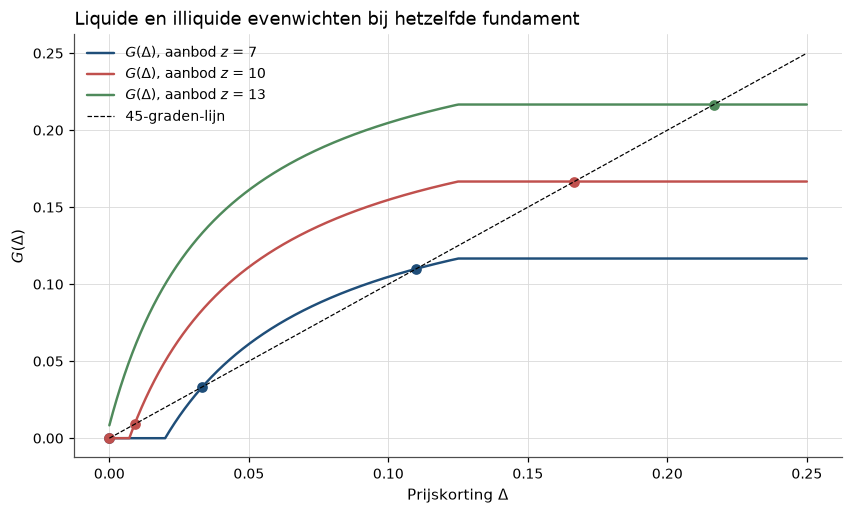

In [3]:
def bp_map(delta, z, K0, x0, h0, theta, eps):
    """Right-hand side G(Delta) of the simplified Brunnermeier-Pedersen fixed point."""
    capital = np.maximum(K0 - x0 * delta, 0.0)
    return np.maximum((z - capital / (h0 + theta * delta)) / eps, 0.0)


BP = dict(K0=1.0, x0=8.0, h0=0.08, theta=2.0, eps=60.0)
grid_d = np.linspace(0.0, 0.25, 5001)
fig, ax = plt.subplots()
for i, z_supply in enumerate([7.0, 10.0, 13.0]):
    gap = bp_map(grid_d, z_supply, **BP) - grid_d
    roots = [optimize.brentq(lambda d: bp_map(d, z_supply, **BP) - d, grid_d[k], grid_d[k + 1])
             for k in np.flatnonzero(np.diff(np.sign(gap)) != 0) if gap[k] != 0]
    roots = sorted(set([0.0] if gap[0] == 0 else []) | set(np.round(roots, 6)))
    ax.plot(grid_d, bp_map(grid_d, z_supply, **BP), color=hap.plotting.COLORS[i], label=f"$G(\\Delta)$, aanbod $z$ = {z_supply:g}")
    ax.plot(roots, roots, "o", color=hap.plotting.COLORS[i])
    print(f"z = {z_supply:>4}: evenwichten Delta* = {roots}")
ax.plot(grid_d, grid_d, color="black", lw=0.8, ls="--", label="45-graden-lijn")
ax.set_title("Liquide en illiquide evenwichten bij hetzelfde fundament")
ax.set_xlabel("Prijskorting $\\Delta$")
ax.set_ylabel("$G(\\Delta)$")
ax.legend()
plt.show()

:::{figure} #cel-intermediaries-bp
:label: fig-intermediaries-bp
:width: 90%

Bij $z = 7$ en $z = 10$ bestaan een liquide evenwicht ($\Delta = 0$) en een illiquide evenwicht
naast elkaar, gescheiden door een instabiel evenwicht (bij $z = 10$ al bij een korting van
0,9%): welke markt er komt, hangt af van verwachtingen en kleine schokken. Bij $z = 7$ hebben de
speculanten in het illiquide evenwicht nog kapitaal, maar is hun marge opgelopen tot 30%; bij
$z = 10$ zijn ze weggevaagd. Bij $z = 13$ overschrijdt het aanbod de opvangcapaciteit
$K_0/h_0 = 12{,}5$ en blijft alleen de illiquide markt over.
:::

### Kapitaalratio en risicopremie: He en Krishnamurthy

*Waarom zou dit waar zijn?* Stel dat alleen intermediairs het risicovolle activum kunnen
houden, en dat huishoudens bij hen hoogstens een vast veelvoud van het vermogen van de
bankiers als eigen vermogen willen inleggen. Zolang de bankiers rijk genoeg zijn, bindt die
grens niet. Na verliezen wel: het eigen vermogen van de sector krimpt, de activa moeten toch
gehouden worden, en de zwaarder gehefboomde marginale houder eist per eenheid risico meer.
{cite:t}`HeKrishnamurthy2013` kalibreren een model met deze *equity capital constraint* en
reproduceren de niet-lineaire sprong van crisispremies en hun snelle terugval; in hun
beleidsanalyse is "injecting equity capital [...] particularly effective".

We nemen de kern over in een vereenvoudigde, lokale versie. De bankiers hebben vermogen
$w_t$, relatieve risicoaversie $\gamma$, en mogen van huishoudens hoogstens $\chi w_t$ eigen
vermogen ophalen. Het risicovolle activum heeft waarde $p_t$, verwacht excess rendement $\pi_t$
en volatiliteit $\sigma_{R,t}$. De intermediair houdt het hele activum, dus zijn kapitaalratio
is $\eta_t = (1+\chi)w_t/p_t$ zolang de restrictie bindt, en een vaste $\bar\eta$ als huishoudens
vrij kapitaal kunnen bijleggen.

:::{prf:proposition} Risicopremie bij een bindende kapitaalrestrictie
:label: thm-intermediaries-hk

Kiest de intermediair zijn portefeuille zoals een Merton-belegger en ruimt de markt, dan is

```{math}
:label: eq-intermediaries-hk-premie
\pi_t = \frac{\gamma\,\sigma_{R,t}^2}{\eta_t}
\quad\text{als } \eta_t < \bar\eta,
\qquad
\pi_t = \frac{\gamma\,\sigma_{R,t}^2}{\bar\eta}
\quad\text{als de restrictie niet bindt.}
```

Bij gegeven volatiliteit is de risicopremie in het beperkte gebied dus omgekeerd evenredig met
de kapitaalratio. Omdat de intermediair de marginale belegger is, is zijn marginale nut de SDF:
$m_{t+1} = \beta\,(w_{t+1}/w_t)^{-\gamma}$ bij consumptie evenredig met vermogen.
:::

:::{prf:proof}
Het optimale aandeel van het eigen vermogen in het risicovolle activum is voor een
CRRA-belegger met constante kansen (zie [](#03-10-merton-icapm)) $\alpha_t = \pi_t/(\gamma\sigma_{R,t}^2)$.
Het eigen vermogen van de sector is $(1+\chi)w_t$ als de restrictie bindt, en het hele activum
moet door de sector gehouden worden, dus $\alpha_t (1+\chi) w_t = p_t$, oftewel
$\alpha_t = p_t/((1+\chi)w_t) = 1/\eta_t$. Gelijkstellen geeft $\pi_t = \gamma\sigma_{R,t}^2/\eta_t$.
Bindt de restrictie niet, dan leggen huishoudens eigen vermogen bij tot de kapitaalratio
$\bar\eta$ is, en geldt hetzelfde met $\bar\eta$. De SDF volgt uit de Euler-vergelijking van
de marginale belegger, [](#eq-intermediaries-sdf) hieronder. $\square$
:::

Maar de volatiliteit is niet gegeven. *Waarom zou dit waar zijn?* Een dividendschok verlaagt
de prijs; de gehefboomde intermediair verliest daarop een veelvoud; zijn kapitaalratio daalt;
de risicopremie stijgt; en een hogere vereiste premie verlaagt de prijs verder. Hoe lager de
kapitaalratio, hoe sterker die terugkoppeling.

Neem een reduced-form prijsregel: dividenden groeien met volatiliteit $\sigma_D$, en een
verhoging van de premie met $\mathrm{d}\pi$ verlaagt de log-prijs met $\tau\,\mathrm{d}\pi$, waarbij
$\tau$ de verwachte duur van een premieschok in jaren is. In het beperkte gebied is
$\eta_t \propto w_t/p_t$ en verandert het vermogen van de bankiers met $1/\eta_t$ maal het
rendement.

:::{prf:proposition} Volatiliteitsversterking
:label: thm-intermediaries-hk-vol

In eerste-orde-benadering, met $\sigma_R$ lokaal constant in de afgeleide van $\pi$, voldoet
de rendementsvolatiliteit in het beperkte gebied aan

```{math}
:label: eq-intermediaries-hk-vol
\sigma_{R}(\eta) = \frac{\sigma_D}{1 - \tau\,\pi(\eta)\left(\frac{1}{\eta} - 1\right)},
\qquad
\pi(\eta) = \frac{\gamma\,\sigma_R(\eta)^2}{\eta}.
```

De kleinste oplossing $\sigma_R(\eta) \ge \sigma_D$ stijgt als $\eta$ daalt, en daarmee stijgt
$\pi(\eta)$ sneller dan $1/\eta$. Onder een kritieke kapitaalratio bestaat geen eindige
oplossing: de terugkoppeling heeft een lusversterking van één of meer.
:::

:::{prf:proof}
Schrijf $\mathrm{d}\log p = \mathrm{d}\log D - \tau\,\mathrm{d}\pi$ en
$\mathrm{d}\log\eta = \mathrm{d}\log w - \mathrm{d}\log p = (1/\eta - 1)\,\mathrm{d}\log p$, omdat
het vermogen van de bankiers met hefboom $1/\eta$ op de prijs reageert. Met
$\pi = \gamma\sigma_R^2/\eta$ en $\sigma_R$ lokaal vast is $\mathrm{d}\pi = -\pi\,\mathrm{d}\log\eta$.
Invullen geeft $\mathrm{d}\log p = \mathrm{d}\log D + \tau\pi(1/\eta - 1)\,\mathrm{d}\log p$; oplossen
naar $\mathrm{d}\log p$ en de standaarddeviatie nemen geeft [](#eq-intermediaries-hk-vol). Laat
$T_\eta(\sigma) = \sigma_D/(1 - \tau\gamma\sigma^2\eta^{-1}(\eta^{-1} - 1))$. $T_\eta$ is stijgend in
$\sigma$, en bij elke $\sigma$ stijgend in $1/\eta$ voor $\eta < 1$. De iteratie
$\sigma_{k+1} = T_\eta(\sigma_k)$ vanaf $\sigma_0 = \sigma_D$ is dus monotoon stijgend en convergeert
naar het kleinste vaste punt als dat bestaat. Voor $\eta' < \eta$ is $T_{\eta'} \ge T_\eta$
puntsgewijs, dus elk iteraat en het kleinste vaste punt zijn groter. Bestaat geen vast punt, dan
divergeert de iteratie. $\square$
:::

De benadering is ruw op één punt: bij $\bar\eta$ springt de volatiliteit, omdat onze prijsregel
het binden van de restrictie niet anticipeert; in het volledige model is de overgang glad.

### Van theorie naar factormodel

*Waarom zou dit waar zijn?* Als het marginale nut van de intermediair de SDF is, moet elk
verwacht excess rendement een beloning zijn voor covariantie met dat marginale nut. Het
marginale nut stijgt als het vermogen van de intermediair daalt, en dat vermogen is het
product van het totale vermogen in de economie en het aandeel van de intermediair daarin.

{cite:t}`HeKellyManela2017` schrijven het vermogen van de intermediair als $\eta_t W_t$, met
$W_t$ het totale vermogen. Met consumptie evenredig met vermogen is dan

```{math}
:label: eq-intermediaries-sdf
m_{t+1} = \beta\left(\frac{\eta_{t+1}W_{t+1}}{\eta_t W_t}\right)^{-\gamma}
\approx a - \gamma\,\frac{\Delta W_{t+1}}{W_t} - \gamma\,\eta^{\Delta}_{t+1},
```

een lineaire SDF in het marktrendement en de groei van de kapitaalratio. Hun factor
$\eta^\Delta_{t+1} = u_{t+1}/\eta_t$ is de innovatie $u_{t+1}$ uit een AR(1) voor de
kapitaalratio, gedeeld door de vorige ratio; ze rapporteren een AR(1)-coëfficiënt van 0,94 per
kwartaal (werkversie, voetnoot 18). Via de bèta-representatie uit [](#02-08-capm) wordt
[](#eq-intermediaries-sdf)

```{math}
:label: eq-intermediaries-twee-factor
\E[R^e_{i}] = \beta_{i,W}\,\lambda_W + \beta_{i,\eta}\,\lambda_\eta,
\qquad \lambda_W > 0,\ \lambda_\eta > 0 .
```

{cite:t}`AdrianEtulaMuir2014` kozen een andere toestandsvariabele. Ze motiveren haar met
Brunnermeier en Pedersen: de Lagrange-multiplier op de financieringsrestrictie is hoog als de
leverage laag is, omdat intermediairs dan gedwongen hebben afgebouwd. Hun SDF is
$m_{t+1} = 1 - b\,\mathrm{LevFac}_{t+1}$, met $\mathrm{LevFac}$ de seizoensgecorrigeerde
verandering in de log-leverage van broker-dealers volgens de Flow of Funds, en $b > 0$. Een
activum dat slecht rendeert als de leverage daalt, is riskant en moet een positieve premie
opleveren: $\lambda_{\mathrm{Lev}} > 0$.

Hier zit de puzzel: AEM vinden een positieve prijs voor schokken in *leverage*, HKM voor
schokken in de *kapitaalratio*, het omgekeerde. HKM schrijven zelf: "These two results are
contradictory because leverage, defined as assets over equity, is just the reciprocal of the
equity capital ratio" (werkversie, p. 4). Twee verschillen maken beide consistent.

Het eerste is boekwaarde tegenover marktwaarde. AEM meten boekleverage uit de Flow of Funds, en
{cite:t}`AdrianShin2010` lieten zien dat "marked-to-market leverage is strongly procyclical":
dealers krimpen hun balans hard als prijzen dalen. HKM meten het eigen vermogen tegen
beurswaarde, die in een crisis veel sneller daalt, omdat de beurs verwachte verliezen meteen
verdisconteert. Het tweede is de samenstelling: de Flow of Funds bevat alleen de
broker-dealeractiviteiten, HKM nemen de beursgenoteerde moeders van de primary dealers. HKM
vinden "little evidence that the accounting treatment of book versus market leverage drives
these differences" en wijzen de samenstelling aan (p. 5). Beide metingen kunnen dus in dezelfde
slechte toestand dalen, zoals in het toy-voorbeeld: de leverage omdat de balans krimpt, de
kapitaalratio omdat het eigen vermogen instort.

## Simulatie: fire sales, premies en de kracht van een factortoets

### (a) Fire sales met twintig intermediairs

Twintig intermediairs met eigen vermogen 1 en leverage uniform tussen 6 en 12 houden hetzelfde
activum; de haircut is $h_0 = 8\%$, dus de maximale leverage 12,5. Een fundamentele schok
verlaagt de prijs; iedere intermediair die boven zijn toegestane balans zit, verkoopt; de
totale verkoop drukt de prijs met $S/(\varepsilon W)$ met $\varepsilon W = 2000$; en we herhalen tot
niemand meer hoeft te verkopen. We vergelijken drie werelden bij dezelfde schokken: zonder
prijsimpact, met fire sales bij een vaste haircut, en met fire sales én een haircut die
oploopt met de cumulatieve prijsdaling, $h = h_0 + \theta(1 - p)$ met $\theta = 1$. De
fundamentele schokken zijn de absolute waarde van een normale trekking met een standaarddeviatie
van 3%, twintigduizend keer.

In [4]:
def fire_sale(shock, leverage, h0, theta, absorb, max_rounds=300):
    """Common-asset fire sale among intermediaries with equity 1 and the given leverage.

    shock is a vector of fundamental price declines (one scenario per entry). In every
    round each intermediary sells down to E / h with h = h0 + theta * (cumulative
    decline); total sales depress the price by sales / absorb. Returns the total price
    decline and the share of intermediaries with non-positive equity, per scenario.
    """
    assets = np.outer(1.0 - shock, leverage)
    equity = 1.0 - np.outer(shock, leverage)
    price = 1.0 - shock
    for _ in range(max_rounds):
        haircut = h0 + theta * (1.0 - price)
        sales = np.clip(assets - np.maximum(equity, 0.0) / haircut[:, None], 0.0, None)
        total = sales.sum(axis=1)
        if total.max() < 1e-10:
            break
        impact = np.minimum(total / absorb, 1.0)
        assets = assets - sales
        loss = assets * impact[:, None]
        assets, equity = assets - loss, equity - loss
        price = price * (1.0 - impact)
    return 1.0 - price, (equity <= 0).mean(axis=1)


N_INTERMEDIARIES, H0_SIM, ABSORB_SIM = 20, 0.08, 2000.0
leverage_sim = rng.uniform(6.0, 12.0, N_INTERMEDIARIES)
shocks_sim = np.abs(rng.normal(0.0, 0.03, 20_000))
worlds = {"geen prijsimpact": (0.0, np.inf), "fire sale, vaste haircut": (0.0, ABSORB_SIM),
          "fire sale + margespiraal": (1.0, ABSORB_SIM)}
declines = {name: fire_sale(shocks_sim, leverage_sim, H0_SIM, theta, absorb)[0]
            for name, (theta, absorb) in worlds.items()}

small, large = shocks_sim < 0.02, shocks_sim > 0.06
pd.DataFrame(
    {name: {"mediane daling (%)": 100 * np.median(d), "95e percentiel (%)": 100 * np.quantile(d, 0.95),
            "99e percentiel (%)": 100 * np.quantile(d, 0.99), "P(daling > 10%)": np.mean(d > 0.10),
            "versterking, schok < 2%": np.median(d[small] / shocks_sim[small]),
            "versterking, schok > 6%": np.median(d[large] / shocks_sim[large])}
     for name, d in declines.items()}
).T.round(3)

,mediane daling (%),95e percentiel (%),99e percentiel (%),P(daling > 10%),"versterking, schok < 2%","versterking, schok > 6%"
geen prijsimpact,2.005,5.976,7.828,0.001,1.000,1.000
"fire sale, vaste haircut",2.247,9.847,13.157,0.047,1.028,1.676
fire sale + margespiraal,5.349,11.747,13.977,0.124,1.287,1.867


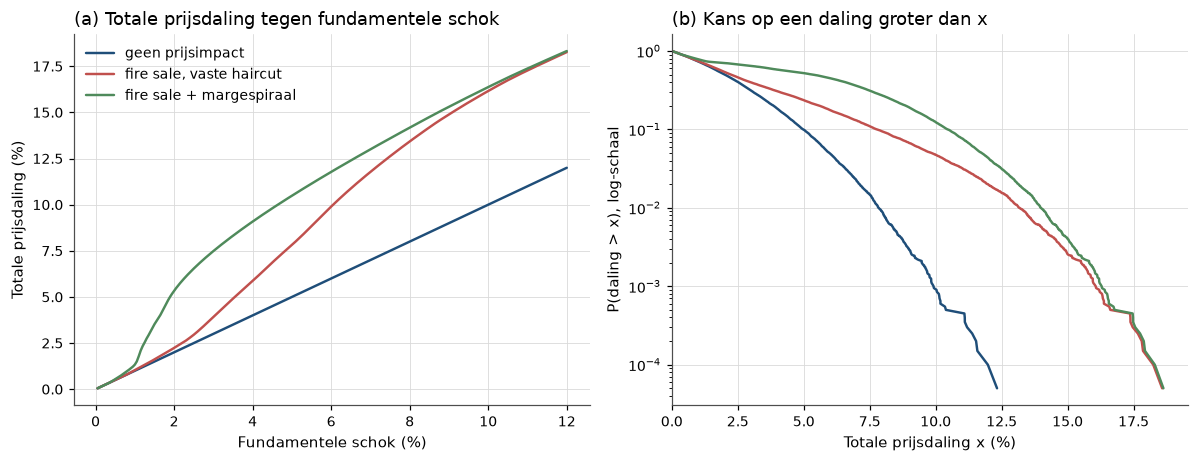

In [5]:
shock_grid = np.linspace(0.0005, 0.12, 240)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for i, (name, (theta, absorb)) in enumerate(worlds.items()):
    curve, _ = fire_sale(shock_grid, leverage_sim, H0_SIM, theta, absorb)
    axes[0].plot(100 * shock_grid, 100 * curve, color=hap.plotting.COLORS[i], label=name)
    tail = np.sort(declines[name])
    axes[1].plot(100 * tail, 1.0 - np.arange(tail.size) / tail.size, color=hap.plotting.COLORS[i], label=name)
axes[0].set_title("(a) Totale prijsdaling tegen fundamentele schok")
axes[0].set_xlabel("Fundamentele schok (%)")
axes[0].set_ylabel("Totale prijsdaling (%)")
axes[0].legend()
axes[1].set_yscale("log")
axes[1].set_xlim(0, None)
axes[1].set_title("(b) Kans op een daling groter dan x")
axes[1].set_xlabel("Totale prijsdaling x (%)")
axes[1].set_ylabel("P(daling > x), log-schaal")
fig.tight_layout()
plt.show()

:::{figure} #cel-intermediaries-firesale
:label: fig-intermediaries-firesale
:width: 100%

Links: kleine schokken worden nauwelijks versterkt, grote wel; de knik ligt waar de eerste
intermediairs hun restrictie raken. Rechts: bij dezelfde verdeling van fundamentele schokken
maken fire sales en vooral de margespiraal de staart van de prijsdalingen veel dikker. Een
risicomodel dat de fundamentele verdeling kent, onderschat de kans op een grote daling met een
orde van grootte.
:::

Bij schokken kleiner dan 2% is de mediane versterking met vaste haircut vrijwel nul (factor
1,03) en met margespiraal 1,29; bij schokken boven 6% worden die factoren 1,68 en 1,87. De kans
op een daling van meer dan 10% gaat van 0,1% zonder prijsimpact naar 4,7% met fire sales en 12%
met de margespiraal. Dat is de niet-lineariteit uit [](#thm-intermediaries-bp): het systeem
gedraagt zich normaal tot het dat niet meer doet, en een steekproef uit de normale jaren zegt
niets over de staart.

### (b) Risicopremie en volatiliteit in een He-Krishnamurthy-economie

We lossen [](#eq-intermediaries-hk-vol) op voor $\gamma = 2$, $\sigma_D = 12\%$ per jaar,
$\tau = 0{,}25$ jaar en $\bar\eta = 0{,}5$. De kapitaalratio in dit model is het deel van de
activa dat met eigen vermogen van de sector gefinancierd is, niet de beurswaarde-ratio van de
primary dealers (die ligt rond 5%); de vorm van de curve telt, niet het niveau.

In [6]:
def hk_premium_vol(eta, gamma=2.0, sigma_d=0.12, tau=0.25, eta_bar=0.5, max_iter=5000):
    """Smallest fixed point of the first-order He-Krishnamurthy amplification (premium, volatility)."""
    eta_eff, sigma = min(eta, eta_bar), sigma_d
    for _ in range(max_iter):
        premium = gamma * sigma**2 / eta_eff
        loop_gain = tau * premium * (1.0 / eta_eff - 1.0) if eta < eta_bar else 0.0
        if loop_gain >= 1.0:
            return np.nan, np.nan
        new = sigma_d / (1.0 - loop_gain)
        if abs(new - sigma) < 1e-12:
            return gamma * new**2 / eta_eff, new
        sigma = new
    return np.nan, np.nan


eta_grid = np.linspace(0.10, 1.0, 361)
hk_curve = pd.DataFrame([hk_premium_vol(e) for e in eta_grid], index=eta_grid, columns=["premie", "volatiliteit"])
eta_crit = hk_curve["premie"].first_valid_index()
print(f"kritieke kapitaalratio (eerste eindige oplossing op het rooster): {eta_crit:.3f}")
hk_curve.iloc[[int(np.abs(eta_grid - e).argmin()) for e in (1.0, 0.5, 0.4, 0.3, 0.25, 0.2)]].round(3)

kritieke kapitaalratio (eerste eindige oplossing op het rooster): 0.198


,premie,volatiliteit
1.00,0.058,0.120
0.50,0.058,0.120
0.40,0.076,0.124
0.30,0.110,0.128
0.25,0.145,0.135
0.20,0.271,0.165


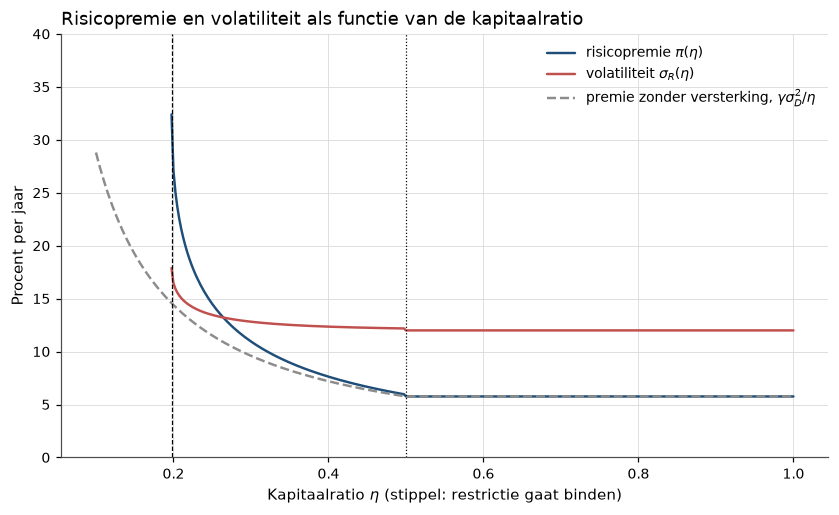

In [7]:
fig, ax = plt.subplots()
ax.plot(hk_curve.index, 100 * hk_curve["premie"], color=hap.plotting.COLORS[0], label="risicopremie $\\pi(\\eta)$")
ax.plot(hk_curve.index, 100 * hk_curve["volatiliteit"], color=hap.plotting.COLORS[1], label="volatiliteit $\\sigma_R(\\eta)$")
ax.plot(hk_curve.index, 100 * 2 * 0.12**2 / np.minimum(hk_curve.index, 0.5), color=hap.plotting.COLORS[7], ls="--",
        label="premie zonder versterking, $\\gamma\\sigma_D^2/\\eta$")
ax.axvline(0.5, color="black", lw=0.8, ls=":")
ax.axvline(eta_crit, color="black", lw=0.8, ls="--")
ax.set_ylim(0, 40)
ax.set_title("Risicopremie en volatiliteit als functie van de kapitaalratio")
ax.set_xlabel("Kapitaalratio $\\eta$ (stippel: restrictie gaat binden)")
ax.set_ylabel("Procent per jaar")
ax.legend()
plt.show()

:::{figure} #cel-intermediaries-hk
:label: fig-intermediaries-hk
:width: 90%

Rechts van $\bar\eta = 0{,}5$ zijn premie en volatiliteit constant. Links daarvan stijgt de
premie eerst ongeveer als $1/\eta$ (grijze stippellijn) en daarna veel sneller, omdat de
volatiliteit zelf toeneemt. Bij de gestreepte lijn is de lusversterking één: daaronder bestaat
in deze benadering geen evenwicht meer, het model van een crash.
:::

Bij $\eta = 0{,}5$ is de premie 5,8% en de volatiliteit 12%; bij $0{,}3$ is de premie 11,0%,
bij $0{,}2$ is ze 27,1% met een volatiliteit van 16,5%. Een halvering van de kapitaalratio van
0,4 naar 0,2 verdubbelt de premie niet maar ruim verdrievoudigt haar. Dat is wat
{cite:t}`HeKrishnamurthy2013` de niet-lineariteit van crisispremies noemen.

### (c) Hoe vaak ziet een factortoets een ware prijs van intermediary-risico?

Stel dat het model waar is: hoe vaak geeft een tweestapstoets op vijftig jaar kwartaaldata een
significante $\lambda_\eta$? We simuleren 35 portefeuilles met marktbèta's rond 1 en
intermediary-bèta's met gemiddelde 0,07 en standaarddeviatie 0,11, de waarden die HKM voor de
25 Fama-French-portefeuilles rapporteren (werkversie, p. 16). De factor heeft een
kwartaalvolatiliteit van 12%, ongeveer die van de HKM-factor, de residuen 4% per kwartaal, en
elke portefeuille een kleine vaste pricing error (standaarddeviatie 0,5% per kwartaal). We
variëren de ware $\lambda_\eta$ van 0 tot 7% per kwartaal, en voegen een *nutteloze factor* toe
die met geen enkel rendement samenhangt {cite}`KanZhang1999`.

In [8]:
def two_pass_arrays(R, F):
    """Two-pass OLS with intercept on arrays: prices of risk, Fama-MacBeth and Shanken (1992) standard errors."""
    # TODO: naar hap.stats (Shanken-correctie voor meerdere factoren in fama_macbeth)
    T, N = R.shape
    betas = np.linalg.lstsq(np.column_stack([np.ones(T), F]), R, rcond=None)[0][1:].T
    Z = np.column_stack([np.ones(N), betas])
    gammas = np.linalg.lstsq(Z, R.T, rcond=None)[0].T
    lam = gammas.mean(axis=0)
    V_fm = np.cov(gammas, rowvar=False) / T
    Sigma_f = np.atleast_2d(np.cov(F, rowvar=False))
    c = lam[1:] @ np.linalg.solve(Sigma_f, lam[1:])
    border = np.zeros_like(V_fm)
    border[1:, 1:] = Sigma_f / T
    V_sh = (1.0 + c) * (V_fm - border) + border
    return lam, np.sqrt(np.diag(V_fm)), np.sqrt(np.clip(np.diag(V_sh), 0.0, None)), betas, Z


def simulate_factor_test(lam_eta, n_sim=1000, T=200, N=35, useless=False):
    """Share of samples with |t| > 1.96 for the intermediary factor in a two-pass test."""
    t_stats, estimates = np.empty((n_sim, 2)), np.empty(n_sim)
    for s in range(n_sim):
        b_m, b_eta = rng.normal(1.0, 0.2, N), rng.normal(0.07, 0.11, N)
        f_m, f_eta = rng.normal(0.015, 0.09, T), rng.normal(0.0, 0.12, T)
        alpha = rng.normal(0.0, 0.005, N)
        R = alpha + 0.015 * b_m + np.outer(f_m - 0.015, b_m) + rng.normal(0.0, 0.04, (T, N))
        if not useless:
            R += lam_eta * b_eta + np.outer(f_eta, b_eta)
        lam, se_fm, se_sh, _, _ = two_pass_arrays(R, np.column_stack([f_m, f_eta]))
        estimates[s], t_stats[s] = lam[2], (lam[2] / se_fm[2], lam[2] / se_sh[2])
    return {"gem. schatting (% p.k.)": 100 * estimates.mean(), "sd schatting (% p.k.)": 100 * estimates.std(),
            "P(|t FM| > 1,96)": np.mean(np.abs(t_stats[:, 0]) > 1.96),
            "P(|t Shanken| > 1,96)": np.mean(np.abs(t_stats[:, 1]) > 1.96)}


power = {f"ware lambda {100 * lam:.0f}%": simulate_factor_test(lam) for lam in (0.0, 0.01, 0.02, 0.03, 0.05, 0.07)}
power["nutteloze factor"] = simulate_factor_test(0.0, useless=True)
power_table = pd.DataFrame(power).T
power_table.round(3)

,gem. schatting (% p.k.),sd schatting (% p.k.),"P(|t FM| > 1,96)","P(|t Shanken| > 1,96)"
ware lambda 0%,-0.036,1.156,0.102,0.101
ware lambda 1%,0.987,1.231,0.244,0.243
ware lambda 2%,1.931,1.228,0.508,0.503
ware lambda 3%,2.861,1.260,0.775,0.772
ware lambda 5%,4.776,1.240,0.981,0.981
ware lambda 7%,6.666,1.265,1.000,1.000
nutteloze factor,-0.168,4.364,0.307,0.275


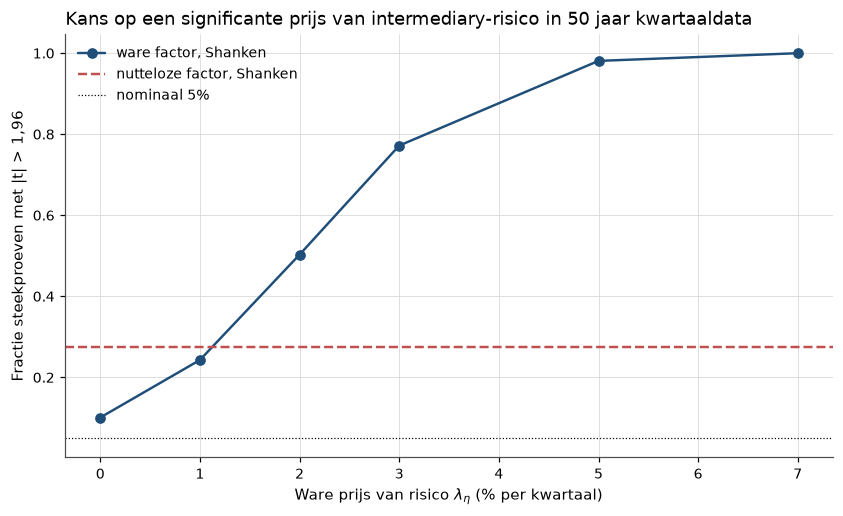

In [9]:
true_lams = [0, 1, 2, 3, 5, 7]
fig, ax = plt.subplots()
ax.plot(true_lams, power_table["P(|t Shanken| > 1,96)"].iloc[:6], "o-", color=hap.plotting.COLORS[0],
        label="ware factor, Shanken")
ax.axhline(power_table.loc["nutteloze factor", "P(|t Shanken| > 1,96)"], color=hap.plotting.COLORS[1], ls="--",
           label="nutteloze factor, Shanken")
ax.axhline(0.05, color="black", lw=0.8, ls=":", label="nominaal 5%")
ax.set_title("Kans op een significante prijs van intermediary-risico in 50 jaar kwartaaldata")
ax.set_xlabel("Ware prijs van risico $\\lambda_\\eta$ (% per kwartaal)")
ax.set_ylabel("Fractie steekproeven met |t| > 1,96")
ax.legend()
plt.show()

:::{figure} #cel-intermediaries-kracht
:label: fig-intermediaries-kracht
:width: 90%

Een prijs van risico van de omvang die HKM rapporteren (7 tot 9% per kwartaal) is in vijftig
jaar vrijwel altijd te zien; een prijs van 2% per kwartaal maar in de helft van de steekproeven.
Tegelijk krijgt een factor die met geen enkel rendement samenhangt, in bijna een derde van de
steekproeven een "significante" prijs zodra het model kleine pricing errors heeft.
:::

Zonder ware prijs verwerpt de toets in 10% in plaats van 5% van de steekproeven, omdat de
pricing errors de nulhypothese van een perfect model schenden. Met een ware prijs van 2% per
kwartaal is de kans op significantie 50%, met 3% ongeveer 77%. De nutteloze factor krijgt in
31% van de steekproeven $|t| > 1{,}96$ volgens Fama-MacBeth en in 28% volgens Shanken, met een
spreiding van de geschatte prijs van 4,4% per kwartaal, bijna vier keer die van een echte
factor. Het mechanisme is dat van {cite:t}`KanZhang1999`: de geschatte bèta's zijn pure ruis,
en de pricing errors worden toevallig aan die ruis toegeschreven. Dit is motief 1 in de
cross-sectie: de standaardfout van de prijs van een niet-verhandelde factor zegt minder dan hij
lijkt.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** He, Kelly & Manela, *Intermediary Asset Pricing: New Evidence from Many Asset
Classes*, Journal of Financial Economics 2017 {cite}`HeKellyManela2017`; gelezen in de
NBER-werkversie w21920 (januari 2016).

**Wat.** (1) De kapitaalratio van de primary dealers, figuur 1, met haar dieptepunt in de
crisis. (2) Tabel 5: tweestapstoetsen met [markt, $\eta^\Delta$] over 1970Q1–2012Q4. HKM vinden
voor alle 125 portefeuilles uit zeven activaklassen samen een prijs van risico van "9% per
quarter with a GMM t-statistic of 2.56 and $R^2$ of 45%", per klasse van 7% voor aandelen tot
22% voor opties, en positief in alle klassen (p. 4 en 17–18). (3) De kapitaalratio voorspelt
toekomstige rendementen (sectie 5).

**Data hier.** `hap.data.hkm("monthly")` en `hap.data.hkm("quarterly")` (kapitaalratio en
factor, 1970–2025); Kenneth French: 25 size/BM-portefeuilles, 10 momentumportefeuilles, FF3 en
momentum via `hap.data.french(...)`; vijf Treasury-portefeuilles met looptijden van 1 tot 5 jaar,
zelf berekend als maandelijkse houdrendementen van zero-coupon-obligaties uit de
Svensson-parameters van `hap.data.gsw()`; FRED `BAA10Y`, `TEDRATE` en `USREC` via
`hap.data.fred(...)`.

**Verschil met het origineel.** HKM gebruiken ook bedrijfsobligaties, staatsobligaties van
opkomende landen, opties, CDS, grondstoffen en valuta; die portefeuilles zijn niet gratis
beschikbaar en ontbreken hier. Hun obligatieportefeuilles komen uit CRSP; de onze zijn
zero-coupon-rendementen uit een geschatte curve. Wij voegen momentumportefeuilles toe, die HKM
niet gebruikten, en rapporteren naast hun steekproef ook 1970–2025. Onze GMM-schatting is een
SDF-schatting zonder intercept met eerste-stapsgewichten; HKM rapporteren GMM-$t$-waarden bij
een regressie met intercept.

**Verwachte afwijking.** Het minimum van de kapitaalratio moet in februari 2009 liggen, rond
2,2% ([](#00-00-setup)). De prijs van intermediary-risico moet op aandelenportefeuilles
positief zijn en in de orde van 7% per kwartaal; de cross-sectionele $R^2$ moet hoger zijn dan
die van het CAPM. Lage kapitaalratio's moeten gevolgd worden door hogere marktrendementen
(negatieve helling). Een negatief teken op de Fama-French-portefeuilles zou een fout in de code
betekenen; een lagere $t$-waarde dan 2,56 is te verwachten, omdat we zes van de zeven
activaklassen missen.
```

### De kapitaalratio in de tijd

In [10]:
hkm_monthly = hap_data.hkm("monthly")
hkm_quarterly = hap_data.hkm("quarterly")
eta_m = hkm_monthly["intermediary_capital_ratio"]
spreads = pd.concat([hap_data.fred(s)[s].resample("ME").mean() for s in ["BAA10Y", "TEDRATE"]], axis=1, sort=True)

print(f"minimum kapitaalratio: {eta_m.min():.2%} in {eta_m.idxmin():%B %Y}")
print(f"correlatie niveau met BAA10Y: {pd.concat([eta_m, spreads['BAA10Y']], axis=1, sort=True).dropna().corr().iloc[0, 1]:.2f},"
      f" met TED-spread: {pd.concat([eta_m, spreads['TEDRATE']], axis=1, sort=True).dropna().corr().iloc[0, 1]:.2f}")
print(f"kwartaalvolatiliteit van de factor: {hkm_quarterly['intermediary_capital_risk_factor'].std():.1%}")
eta_m.resample("YE").mean().loc["2005":"2012"].rename("gemiddelde kapitaalratio").to_frame().T.round(3)

minimum kapitaalratio: 2.23% in February 2009
correlatie niveau met BAA10Y: -0.33, met TED-spread: -0.14
kwartaalvolatiliteit van de factor: 12.3%


date,2005-12-31,2006-12-31,2007-12-31,2008-12-31,2009-12-31,2010-12-31,2011-12-31,2012-12-31
gemiddelde kapitaalratio,0.078,0.082,0.068,0.041,0.04,0.049,0.044,0.043


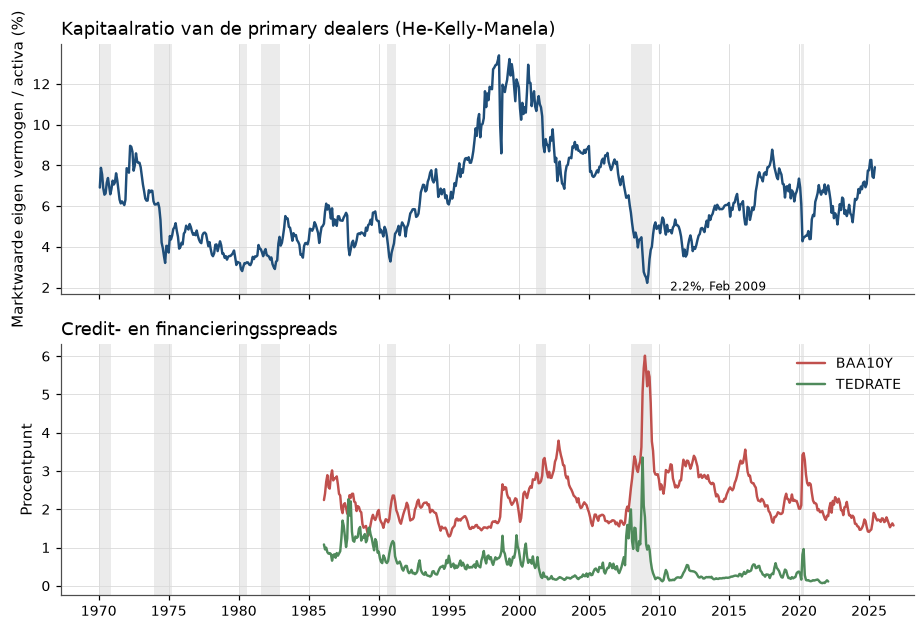

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(eta_m.index, 100 * eta_m, color=hap.plotting.COLORS[0])
axes[0].annotate(f"{eta_m.min():.1%}, {eta_m.idxmin():%b %Y}", (eta_m.idxmin(), 100 * eta_m.min()),
                 xytext=(15, -5), textcoords="offset points", fontsize=8)
axes[0].set_title("Kapitaalratio van de primary dealers (He-Kelly-Manela)")
axes[0].set_ylabel("Marktwaarde eigen vermogen / activa (%)")
hap.plotting.recession_shading(axes[0])
for i, s in enumerate(["BAA10Y", "TEDRATE"]):
    axes[1].plot(spreads.index, spreads[s], color=hap.plotting.COLORS[i + 1], label=s)
axes[1].set_title("Credit- en financieringsspreads")
axes[1].set_ylabel("Procentpunt")
axes[1].set_xlabel("Jaar")
axes[1].legend()
hap.plotting.recession_shading(axes[1])
hap.plotting.timeline_axis(axes[1], every=5)
plt.show()

:::{figure} #cel-intermediaries-kapitaalratio
:label: fig-intermediaries-kapitaalratio
:width: 100%

De kapitaalratio daalt in bijna elke recessie, en nergens zo diep als in 2008–2009, toen de
spreads op bedrijfsobligaties en interbancaire leningen hun hoogste niveau van de steekproef
bereikten. De dip en het herstel rond 1998 vallen samen met LTCM, zonder recessie.
:::

Het dieptepunt ligt op 2,23% in februari 2009, zoals verwacht. Het jaargemiddelde daalde van
8,2% in 2006 via 6,8% in 2007 naar 4,1% in 2008 en 4,0% in 2009, en was in 2011 met 4,4% nog
niet hersteld. Het niveau van de kapitaalratio correleert met $-0{,}33$ met de Baa-spread en
$-0{,}14$ met de TED-spread: lage kapitaalratio's gaan samen met hoge spreads, maar het verband
is niet mechanisch.

### Broker-dealer-leverage uit de Flow of Funds

```{admonition} Replicatie
:class: seealso

**Bron.** Adrian, Etula & Muir, *Financial Intermediaries and the Cross-Section of Asset
Returns*, Journal of Finance 2014 {cite}`AdrianEtulaMuir2014`; gelezen in Federal Reserve Bank
of New York Staff Report 464 (herzien september 2013).

**Wat.** Hun eenfactormodel "prices size, book-to-market, momentum, and bond portfolios with an
$R^2$ of 77 percent and an average annual pricing error of 1 percent" (samenvatting). In de
werkversie, tabel III en p. 15–18: 25 size/BM-, 10 momentum- en 6 Treasury-portefeuilles over
1968Q1–2009Q4, intercept 12 basispunten, MAPE 1,3% per jaar, prijs van leverage-risico 62% per
jaar, tegen een aangepaste $R^2$ van 10% voor het CAPM, 16% voor Fama-French en 81% voor een
vijffactormodel met momentum en een obligatiefactor.

**Data hier.** FRED `BOGZ1FL664090005Q` (Security Brokers and Dealers; Total Financial Assets)
en `BOGZ1FL664190005Q` (Total Liabilities), kwartaal, niet seizoensgecorrigeerd, via
`hap.data.fred(...)`. Leverage $=$ activa$/$(activa $-$ schulden), zoals hun vergelijking (4);
de factor is de verandering in de log-leverage, gecorrigeerd voor kwartaalgemiddelden.

**Verschil met het origineel.** AEM gebruikten tabel L.129 van de Flow of Funds van toen; de
Z.1-cijfers zijn sindsdien herzien en herschikt. Hun seizoenscorrectie gebruikt een
uitbreidend venster, de onze de hele steekproef (kijkt vooruit). Hun obligaties komen uit CRSP.

**Verwachte afwijking.** De boekleverage moet in 2008–2009 sterk dalen (procyclisch), terwijl
de kapitaalratio van HKM tegelijk daalt. De prijs van leverage-risico moet positief zijn. Een
$R^2$ van 77% halen we waarschijnlijk niet, omdat de onderliggende reeks herzien is.
```

In [12]:
assets_bd = hap_data.fred("BOGZ1FL664090005Q")["BOGZ1FL664090005Q"]
liabilities_bd = hap_data.fred("BOGZ1FL664190005Q")["BOGZ1FL664190005Q"]
book_leverage = assets_bd / (assets_bd - liabilities_bd)
book_leverage.index = book_leverage.index + pd.offsets.QuarterEnd(0)      # FRED stamps the quarter start
dlog_lev = np.log(book_leverage).diff().loc["1968":]
lev_factor = (dlog_lev - dlog_lev.groupby(dlog_lev.index.quarter).transform("mean") + dlog_lev.mean()).rename("lev")
eta_factor = hkm_quarterly["intermediary_capital_risk_factor"].rename("eta")
eta_q = hkm_quarterly["intermediary_capital_ratio"]

crisis = pd.concat([book_leverage.rename("boekleverage (FoF)"), lev_factor.rename("AEM-factor"),
                    eta_q.rename("kapitaalratio (HKM)"), (1 / eta_q).rename("marktleverage (HKM)"),
                    eta_factor.rename("HKM-factor")], axis=1, sort=True)
changes = pd.concat([np.log(book_leverage).diff(), np.log(1 / eta_q).diff()], axis=1, sort=True).dropna()
print(f"correlatie AEM-factor en HKM-factor: {crisis[['AEM-factor', 'HKM-factor']].dropna().corr().iloc[0, 1]:.2f}")
print(f"correlatie log-veranderingen boekleverage (FoF) en marktleverage (HKM): {changes.corr().iloc[0, 1]:.2f}")
crisis.loc["2007-06":"2009-12"].round(3)

correlatie AEM-factor en HKM-factor: 0.06
correlatie log-veranderingen boekleverage (FoF) en marktleverage (HKM): -0.10


,boekleverage (FoF),AEM-factor,kapitaalratio (HKM),marktleverage (HKM),HKM-factor
date,,,,,
2007-06-30,44.973,0.022,0.070,14.205,0.010
2007-09-30,44.813,-0.007,0.064,15.528,-0.076
2007-12-31,45.590,0.003,0.057,17.606,-0.114
2008-03-31,46.959,0.053,0.045,22.422,-0.218
2008-06-30,41.187,-0.137,0.040,25.189,-0.127
2008-09-30,43.046,0.040,0.045,22.371,0.097
2008-12-31,30.779,-0.350,0.026,38.462,-0.437
2009-03-31,28.083,-0.068,0.026,37.736,-0.052
2009-06-30,24.358,-0.148,0.040,24.938,0.445


De boekleverage van de broker-dealersector daalde van 47,0 in het eerste kwartaal van 2008
naar 22,6 eind 2009: gehalveerd, precies het procyclische patroon van {cite:t}`AdrianShin2010`.
In dezelfde periode daalde de kapitaalratio van de primary dealers van 4,5% naar 2,6% eind
2008, dus steeg hun marktleverage van 22 naar 38. De log-veranderingen van de twee leverages
correleren met $-0{,}10$. Toch zijn beide factoren in het vierde kwartaal van 2008 sterk negatief
($-0{,}44$ en $-0{,}35$): in het slechtste kwartaal van de steekproef wijzen ze dezelfde kant op,
zoals het toy-voorbeeld voorspelde. Over de hele steekproef is hun correlatie 0,06. Het zijn
verschillende metingen van hetzelfde begrip, en daardoor ook bijna onafhankelijke factoren.

### De cross-sectie

We bouwen kwartaalrendementen door maandrendementen samen te stellen, trekken het
samengestelde risicovrije rendement af en schatten voor elk model (i) de tweestapstoets met
intercept, met Shanken-$t$-waarden, en (ii) een GMM-schatting van de SDF
$m = 1 - (\mathbf{f} - \E\mathbf{f})^\top\mathbf{b}$ zonder intercept, met
$\boldsymbol{\lambda} = \Cov(\mathbf{f})\,\mathbf{b}$ en Newey-West-gewichten (twee lags) in de
spreidingsmatrix. De Treasury-portefeuilles zijn de houdrendementen van zero-coupon-obligaties
van 1 tot 5 jaar: $\log(P_{t+1}(n - 1/12)/P_t(n))$ met $\log P_t(n) = -n\,y_t(n)$ en $y_t(n)$ uit
de Svensson-curve.

In [13]:
gsw = hap_data.gsw()
svensson = gsw[["BETA0", "BETA1", "BETA2", "BETA3", "TAU1", "TAU2"]].dropna(subset=["BETA0", "TAU1"]).resample("ME").last()
svensson = svensson.fillna({"BETA3": 0.0, "TAU2": 1.0})


def svensson_yield(par, maturity):
    """Continuously compounded zero-coupon yield from Svensson parameters (decimals, maturity in years)."""
    x1, x2 = maturity / par["TAU1"], maturity / par["TAU2"]
    s1, s2 = (1 - np.exp(-x1)) / x1, (1 - np.exp(-x2)) / x2
    return par["BETA0"] + par["BETA1"] * s1 + par["BETA2"] * (s1 - np.exp(-x1)) + par["BETA3"] * (s2 - np.exp(-x2))


bond_returns = pd.DataFrame({
    f"OBL {n}j": np.exp(-(n - 1 / 12) * svensson_yield(svensson, n - 1 / 12).shift(-1) + n * svensson_yield(svensson, n)).shift(1) - 1
    for n in (1, 2, 3, 4, 5)
})

ff3 = hap_data.french("F-F_Research_Data_Factors")
momentum_factor = hap_data.french("F-F_Momentum_Factor")
size_bm = hap_data.french("25_Portfolios_5x5")
momentum_dec = hap_data.french("10_Portfolios_Prior_12_2").add_prefix("MOM ")
monthly = pd.concat([size_bm, momentum_dec, bond_returns, ff3, momentum_factor], axis=1, sort=True).dropna(subset=["RF"])


def to_quarterly(frame):
    """Compound monthly simple returns to quarters; quarters with missing months become NaN."""
    return ((1 + frame).resample("QE").prod() - 1).where(frame.resample("QE").count() == 3)


quarterly = to_quarterly(monthly)
cols_25, cols_mom, cols_bond = list(size_bm.columns), list(momentum_dec.columns), list(bond_returns.columns)
excess_q = quarterly[cols_25 + cols_mom + cols_bond].sub(quarterly["RF"], axis=0)
factors_q = pd.DataFrame({"Mkt": to_quarterly(ff3["Mkt-RF"] + ff3["RF"]) - quarterly["RF"],
                          "SMB": to_quarterly(ff3["SMB"]), "HML": to_quarterly(ff3["HML"]),
                          "Mom": to_quarterly(momentum_factor["Mom"])})
factors_q = pd.concat([factors_q, eta_factor, lev_factor], axis=1, sort=True)
print(f"correlatie HKM-factor met het marktrendement: {factors_q[['eta', 'Mkt']].dropna().corr().iloc[0, 1]:.2f}")
excess_q.loc["1970":].describe().loc[["count", "mean", "std"]].T.groupby(lambda c: c.split()[0]).mean().round(4)

correlatie HKM-factor met het marktrendement: 0.76


,count,mean,std
BIG,226.0,0.0235,0.1030
ME1,226.0,0.0265,0.1265
ME2,226.0,0.0262,0.1216
ME3,226.0,0.0250,0.1116
ME4,226.0,0.0243,0.1054
ME5,226.0,0.0194,0.0841
MOM,226.0,0.0194,0.1052
OBL,226.0,0.0041,0.0227
SMALL,226.0,0.0225,0.1488


In [14]:
def two_pass(excess, factors):
    """Two-pass test with intercept on DataFrames; returns prices of risk, Shanken t, R2, MAPE and pricing errors."""
    data = pd.concat([excess, factors], axis=1, sort=True).dropna()
    R, F = data[excess.columns].to_numpy(), data[factors.columns].to_numpy()
    lam, _, se_sh, _, Z = two_pass_arrays(R, F)
    errors = R.mean(axis=0) - Z @ lam
    names = ["const", *factors.columns]
    return {"T": len(R), "lam": pd.Series(lam, names), "t_shanken": pd.Series(lam / se_sh, names),
            "r2": 1 - errors.var() / R.mean(axis=0).var(), "mape": np.abs(errors).mean(),
            "mean": pd.Series(R.mean(axis=0), excess.columns), "fitted": pd.Series(Z @ lam, excess.columns)}


def gmm_sdf(excess, factors, lags=2):
    """First-stage GMM for m = 1 - (f - E f)'b with the factor means as extra moments (Cochrane 2005, ch. 13)."""
    # TODO: naar hap.stats (GMM-schatting van een lineaire SDF)
    data = pd.concat([excess, factors], axis=1, sort=True).dropna()
    R, F = data[excess.columns].to_numpy(), data[factors.columns].to_numpy()
    T, N = R.shape
    K = F.shape[1]
    F_dm = F - F.mean(axis=0)
    D, mean_R = R.T @ F_dm / T, R.mean(axis=0)
    b = np.linalg.lstsq(D, mean_R, rcond=None)[0]
    u = np.column_stack([R * (1 - F_dm @ b)[:, None], F_dm])
    u = u - u.mean(axis=0)
    S = u.T @ u / T
    for j in range(1, lags + 1):
        gamma_j = u[j:].T @ u[:-j] / T
        S += (1 - j / (lags + 1)) * (gamma_j + gamma_j.T)
    d = np.block([[-D, mean_R[:, None] * b[None, :]], [np.zeros((K, K)), -np.eye(K)]])
    a = np.block([[D.T, np.zeros((K, K))], [np.zeros((K, N)), np.eye(K)]])
    ad_inv = np.linalg.inv(a @ d)
    V = ad_inv @ a @ S @ a.T @ ad_inv.T / T
    Sigma_f = np.atleast_2d(np.cov(F, rowvar=False, bias=True))
    lam = Sigma_f @ b
    se_lam = np.sqrt(np.diag(Sigma_f @ V[:K, :K] @ Sigma_f))
    errors = mean_R - D @ b
    return {"lam": pd.Series(lam, factors.columns), "t": pd.Series(lam / se_lam, factors.columns),
            "r2": 1 - (errors**2).sum() / ((mean_R - mean_R.mean())**2).sum()}


MODELS = {"CAPM": ["Mkt"], "FF3": ["Mkt", "SMB", "HML"], "Carhart": ["Mkt", "SMB", "HML", "Mom"],
          "HKM": ["Mkt", "eta"], "AEM": ["lev"]}
TEST_SETS = [("FF25, 1970–2012", "1970", "2012", cols_25),
             ("25+10+5 obl., 1970–2012", "1970", "2012", cols_25 + cols_mom + cols_bond),
             ("25+10+5 obl., 1970–2025", "1970", "2025", cols_25 + cols_mom + cols_bond)]

rows, fits = {}, {}
for label, start, end, cols in TEST_SETS:
    for model, fcols in MODELS.items():
        R_s, F_s = excess_q.loc[start:end, cols], factors_q.loc[start:end, fcols]
        tp, gm = two_pass(R_s, F_s), gmm_sdf(R_s, F_s)
        key = {"HKM": "eta", "AEM": "lev"}.get(model)
        rows[(label, model)] = {
            "kwartalen": tp["T"],
            "λ interm. (% p.k.)": 100 * tp["lam"][key] if key else np.nan,
            "t Shanken": tp["t_shanken"][key] if key else np.nan,
            "λ GMM (% p.k.)": 100 * gm["lam"][key] if key else np.nan,
            "t GMM": gm["t"][key] if key else np.nan,
            "R² twee stappen": tp["r2"], "MAPE (% p.k.)": 100 * tp["mape"], "R² GMM": gm["r2"],
        }
        fits[(label, model)] = tp
cross_section = pd.DataFrame(rows).T
cross_section.round(2)

kwartalen  λ interm. (% p.k.)  t Shanken  \
FF25, 1970–2012         CAPM         172.0                 NaN        NaN   
                        FF3          172.0                 NaN        NaN   
                        Carhart      172.0                 NaN        NaN   
                        HKM          172.0                4.98       1.61   
                        AEM          172.0                4.76       0.98   
25+10+5 obl., 1970–2012 CAPM         172.0                 NaN        NaN   
                        FF3          172.0                 NaN        NaN   
                        Carhart      172.0                 NaN        NaN   
                        HKM          172.0                3.44       1.94   
                        AEM          172.0                8.79       2.08   
25+10+5 obl., 1970–2025 CAPM         224.0                 NaN        NaN   
                        FF3          224.0                 NaN        NaN   
                        Carhart      224.0                 NaN        NaN   
                        HKM          221.0                3.57       2.48   
                        AEM          224.0               10.34       2.69   

                                 λ GMM (% p.k.)  t GMM  R² twee stappen  \
FF25, 1970–2012         CAPM                NaN    NaN             0.09   
                        FF3                 NaN    NaN             0.73   
                        Carhart             NaN    NaN             0.75   
                        HKM                6.96   3.10             0.44   
                        AEM                8.67   1.37             0.08   
25+10+5 obl., 1970–2012 CAPM                NaN    NaN             0.12   
                        FF3                 NaN    NaN             0.37   
                        Carhart             NaN    NaN             0.85   
                        HKM                4.94   2.44             0.22   
                        AEM                8.15   1.36             0.41   
25+10+5 obl., 1970–2025 CAPM                NaN    NaN             0.27   
                        FF3                 NaN    NaN             0.48   
                        Carhart             NaN    NaN             0.84   
                        HKM                4.76   2.74             0.39   
                        AEM               11.79   1.28             0.42   

                                 MAPE (% p.k.)  R² GMM  
FF25, 1970–2012         CAPM              0.54   -0.61  
                        FF3               0.25    0.61  
                        Carhart           0.23    0.73  
                        HKM               0.37    0.41  
                        AEM               0.56    0.03  
25+10+5 obl., 1970–2012 CAPM              0.62   -0.09  
                        FF3               0.47    0.27  
                        Carhart           0.23    0.82  
                        HKM               0.56    0.08  
                        AEM               0.54    0.41  
25+10+5 obl., 1970–2025 CAPM              0.51    0.06  
                        FF3               0.39    0.39  
                        Carhart           0.24    0.81  
                        HKM               0.46    0.23  
                        AEM               0.50    0.41

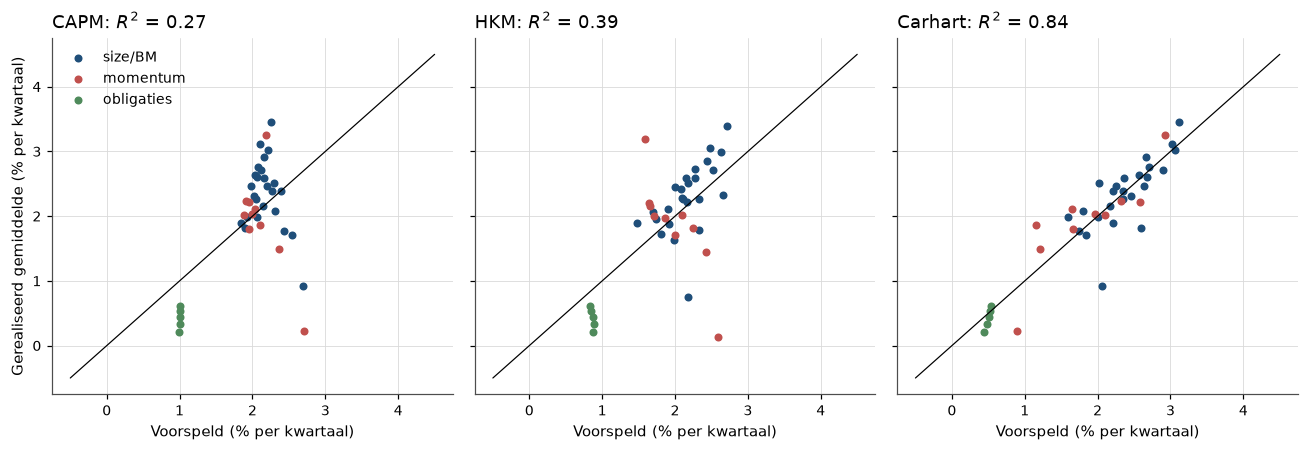

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharex=True, sharey=True)
groups = {"size/BM": cols_25, "momentum": cols_mom, "obligaties": cols_bond}
for ax, model in zip(axes, ["CAPM", "HKM", "Carhart"], strict=True):
    fit = fits[("25+10+5 obl., 1970–2025", model)]
    for i, (group, cols) in enumerate(groups.items()):
        ax.scatter(100 * fit["fitted"][cols], 100 * fit["mean"][cols], s=18, color=hap.plotting.COLORS[i], label=group)
    ax.plot([-0.5, 4.5], [-0.5, 4.5], color="black", lw=0.8)
    ax.set_title(f"{model}: $R^2$ = {fit['r2']:.2f}")
    ax.set_xlabel("Voorspeld (% per kwartaal)")
axes[0].set_ylabel("Gerealiseerd gemiddelde (% per kwartaal)")
axes[0].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-intermediaries-cross
:label: fig-intermediaries-cross
:width: 100%

Gemiddelde kwartaalrendementen 1970–2025 tegen de voorspelling van drie modellen. Het CAPM
kent de obligaties en aandelen een gemeenschappelijke lijn toe maar mist de spreiding binnen
de aandelen. Het HKM-model trekt de size/BM-portefeuilles in de goede richting en laat de
momentumportefeuilles, die het niet kan verklaren, als een verticale wolk staan. Carhart, met
een factor die op momentum gesorteerd is, legt die wolk op de lijn.
:::

Op de 25 size/BM-portefeuilles over de steekproef van HKM is de GMM-schatting van de prijs van
intermediary-risico 6,96% per kwartaal met $t = 3{,}10$, vrijwel precies de 7% voor aandelen
uit HKM's tabel 5; de tweestapsschatting met intercept is lager, 4,98% met een Shanken-$t$ van
1,61. De cross-sectionele $R^2$ is 0,44, tegen 0,09 voor het CAPM, maar 0,73 voor Fama-French.
Met momentum- en obligatieportefeuilles erbij daalt de tweestapsschatting naar 3,4% per
kwartaal ($t = 1{,}94$) en de $R^2$ naar 0,22, nog altijd boven het CAPM (0,12) maar ver onder
Carhart (0,85). Over 1970–2025 is de prijs 3,6% per kwartaal met een Shanken-$t$ van 2,48 en een
GMM-$t$ van 2,74. Het teken is dus overal positief en in de meeste specificaties significant, maar
het model verklaart momentum niet: zonder obligaties en met momentum is de tweestapsschatting
over 1970–2025 zelfs nul (oefening 2).

De AEM-factor doet het in onze data duidelijk slechter dan in het artikel. Op 25+10+5 obligaties
over 1970–2012 is de prijs positief, 8,8% per kwartaal met een Shanken-$t$ van 2,08, maar de
$R^2$ is 0,41 in plaats van 77%, en de GMM-$t$ is maar 1,36. Het verschil kan zitten in de
obligaties (zes CRSP-portefeuilles tegenover vijf zero-coupon-reeksen), in de herziene Flow of
Funds of in de seizoenscorrectie; met gratis data kunnen we dat niet uitmaken.

### Voorspelt de kapitaalratio rendementen en spreads?

HKM rapporteren dat de kapitaalratio toekomstige rendementen voorspelt in vijf van de zeven
activaklassen (werkversie, p. 6). We regresseren het cumulatieve excess marktrendement over $h$
maanden op het niveau van de kapitaalratio, en de verandering in de Baa-spread over $h$ maanden
op hetzelfde niveau. Omdat de kapitaalratio zeer persistent is en de horizonnen overlappen,
gebruiken we de standaardfouten van {cite:t}`Hodrick1992` (variant 1B), die de overlap in de
regressor stoppen in plaats van in de residuen; zie [](#04-20-voorspelbaarheid) voor de
Stambaugh-bias die daarbovenop komt.

In [16]:
def hodrick_1b(y, x, horizon):
    """Regress y_{t+1} + ... + y_{t+h} on x_t; Hodrick (1992) 1B standard errors under no predictability."""
    # TODO: naar hap.stats (method="hodrick-1b" in long_horizon_regression)
    frame = pd.concat([y.rename("y"), x.rename("x")], axis=1, sort=True).dropna()
    r, z = frame["y"].to_numpy(), frame["x"].to_numpy()
    T = len(r)
    target = np.convolve(r, np.ones(horizon), "valid")[1:]
    n = len(target)
    X = np.column_stack([np.ones(n), z[:n]])
    coef = np.linalg.lstsq(X, target, rcond=None)[0]
    shocks = r[1:] - r[1:].mean()
    cum = np.vstack([np.zeros(2), np.cumsum(np.column_stack([np.ones(T), z]), axis=0)])
    idx = np.arange(horizon - 1, T - 1)
    rolled = cum[idx + 1] - cum[idx + 1 - horizon]            # x_t + ... + x_{t-h+1}
    S = (rolled * shocks[idx, None] ** 2).T @ rolled / n
    Q_inv = np.linalg.inv(X.T @ X / n)
    V = Q_inv @ S @ Q_inv / n
    resid = target - X @ coef
    return {"helling": coef[1], "t (Hodrick 1B)": coef[1] / np.sqrt(V[1, 1]), "R²": 1 - resid.var() / target.var(),
            "waarnemingen": n}


market_m = ff3["Mkt-RF"].loc["1970":]
baa_change = spreads["BAA10Y"].diff() / 100
predict = {("marktrendement", h): hodrick_1b(market_m, eta_m, h) for h in (1, 12, 24, 36)}
predict.update({("verandering Baa-spread", h): hodrick_1b(baa_change, eta_m, h) for h in (1, 12, 24)})
pd.DataFrame(predict).T.rename_axis(["te voorspellen", "horizon (maanden)"]).round(3)

helling  t (Hodrick 1B)     R²  \
te voorspellen         horizon (maanden)                                   
marktrendement         1                   -0.138          -1.488  0.005   
                       12                  -1.390          -1.361  0.037   
                       24                  -2.946          -1.499  0.091   
                       36                  -4.087          -1.429  0.136   
verandering Baa-spread 1                    0.003           0.719  0.001   
                       12                   0.082           1.778  0.066   
                       24                   0.148           1.914  0.139   

                                          waarnemingen  
te voorspellen         horizon (maanden)                
marktrendement         1                         664.0  
                       12                        653.0  
                       24                        641.0  
                       36                        629.0  
verandering Baa-spread 1                         471.0  
                       12                        460.0  
                       24                        448.0

Het teken klopt. Een kapitaalratio die één procentpunt lager ligt, gaat samen met een
marktrendement dat over het volgende jaar 1,4 procentpunt en over drie jaar 4,1 procentpunt
hoger ligt, en met een Baa-spread die over het volgende jaar 8 basispunten meer daalt. Maar
geen van de Hodrick-$t$-waarden haalt 1,96: $-1{,}36$ op een jaar en $-1{,}43$ op drie jaar
voor de markt, $1{,}78$ en $1{,}91$ voor de spread. De $R^2$ van 13,6% op drie jaar ziet er
indrukwekkend uit, maar is voor een groot deel de overlap. Met 55 jaar maanddata en in feite
een handvol crises (1974, 1990, 2008) is dit het 2%-motief in de tijdreeks: de voorspellende
kracht rust op dezelfde paar episodes die de kapitaalratio laag maakten.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Intermediary asset pricing gaf 2008 een mechanisme dat
consumptiemodellen missen: gedwongen verkopen, marges die met de volatiliteit oplopen, en een
marginale belegger wiens kapitaal in een paar kwartalen verdwijnt. Het verklaart waarom
liquiditeit overal tegelijk opdroogt, waarom premies niet-lineair exploderen en snel terugvallen,
en waarom identieke kasstromen verschillende prijzen kregen: bij {cite:t}`GarleanuPedersen2011`
worden vereiste rendementen bepaald door "their betas and their margin requirements", en
{cite:t}`MitchellPulvino2012` beschreven hoe hedgefondsen na de val van hun prime brokers
"became unable to maintain similar prices of similar assets". De data geven het model gelijk op
het teken: de kapitaalratio bereikte in februari 2009 2,2%, en haar schokken hebben op aandelen-
en obligatieportefeuilles een positieve prijs, voor aandelen in de orde die HKM rapporteren.

**Waar het breekt.** Op de meting. Twee factoren die elkaars omgekeerde zouden moeten zijn,
leverage en kapitaalratio, krijgen allebei een positieve prijs, correleren in onze data met 0,06,
en de boekleverage halveerde in 2008–2009 terwijl de marktleverage bijna verdubbelde. De $R^2$
van 77% van AEM halen we met de huidige Flow of Funds niet (0,41), en het HKM-model laat
momentum volledig liggen. De HKM-factor correleert bovendien met 0,76 met het marktrendement;
een deel van zijn succes kan de bèta van dealeraandelen zijn in plaats van hun kapitaal. En
[](#fig-intermediaries-kracht) waarschuwt dat een niet-verhandelde factor ook zonder enige
samenhang met rendementen in bijna een derde van de steekproeven "significant" kan zijn.

**Risico of vergissing?** De Chicago-lezing: de intermediair is de marginale belegger, zijn
marginale nut is de SDF, en de hoge premies van 2008 waren de rationele prijs van risico in een
toestand waarin kapitaal schaars was. Wie toen kocht, werd betaald voor beprijsd risico,
Santa-Clara's praktijkmotief. De Yale-lezing: dit zijn de limits of arbitrage van
[](#04-23-behavioral) op macroschaal; prijzen weken af omdat arbitrageurs moesten verkopen, en
dat identieke kasstromen verschillende prijzen kregen, is voor dit kamp een mispricing en geen
premie. Beide lezingen zijn het eens over de kapitaalratio, de spreads en de bases. Scheiden zou
kunnen met de posities van de marginale kopers: liepen de kortingen terug zodra kapitaal
binnenkwam, ongeacht het risico? Die data is grotendeels niet publiek. Santa-Clara's les nummer
tien geldt voor beide: "Leverage plus mark-to-market plus a deadline is the recipe for ruin"
{cite}`SantaClara2026`.

**Wat er daarna kwam.** Als dezelfde feiten, voorspelbare premies die in crises exploderen,
zowel een rationele discontovoet als een tijdelijke mispricing kunnen zijn, is de vraag wat het
vakgebied daar in 2013 mee deed, toen Fama en Shiller samen de Nobelprijs kregen:
[](#05-33-fama-vs-shiller).

## Oefeningen

:::{exercise}
:label: ex-intermediaries-1

**De liquiditeitsspiraal ontleed.** Neem het vereenvoudigde Brunnermeier-Pedersen-model met
$K_0 = 1$, $x_0 = 8$, $h_0 = 0{,}08$, $\varepsilon = 60$ en $z = 13$.

1. Laat zien dat de liquide markt geen evenwicht is, en vind voor $\theta = 0$ het evenwicht
   $\Delta^*$ met de hand: los $\Delta = (z - (K_0 - x_0\Delta)/h_0)/\varepsilon$ op.
2. Bereken met [](#eq-intermediaries-bp-multiplier) de multiplier $\mathrm{d}\Delta^*/\mathrm{d}z$
   voor $\theta = 0$ en voor $\theta = 0{,}5$, en splits $G'$ in de verliesspiraal en de
   margespiraal. Controleer met een eindige differentie.
3. Voor welke $x_0$ wordt het evenwicht bij $\theta = 0$ instabiel?
:::

:::{solution} ex-intermediaries-1
:class: dropdown

**(1)** $z = 13 > K_0/h_0 = 12{,}5$, dus $G(0) > 0$. Bij $\theta = 0$ en bindende restrictie is
$\varepsilon\Delta = z - K_0/h_0 + x_0\Delta/h_0$, dus $\Delta^*(\varepsilon - x_0/h_0) = z - K_0/h_0$.
Met $x_0/h_0 = 100 > \varepsilon = 60$ is $\Delta^* = 0{,}5/(-40) < 0$: er is geen evenwicht met
bindende restrictie en positief kapitaal; de oplossing is het illiquide evenwicht
$\Delta^* = z/\varepsilon = 0{,}2167$, waar het kapitaal op is ($K_0/x_0 = 0{,}125 < 0{,}2167$).
Met $x_0 = 3$ is $x_0/h_0 = 37{,}5 < 60$ en $\Delta^* = 0{,}5/22{,}5 = 0{,}0222$.

In [17]:
def bp_equilibrium(z, K0, x0, h0, theta, eps):
    """Smallest positive fixed point of the simplified Brunnermeier-Pedersen map."""
    grid = np.linspace(1e-9, z / eps, 200_001)
    gap = bp_map(grid, z, K0, x0, h0, theta, eps) - grid
    k = np.flatnonzero(np.diff(np.sign(gap)) != 0)
    return optimize.brentq(lambda d: bp_map(d, z, K0, x0, h0, theta, eps) - d, grid[k[0]], grid[k[0] + 1]) if k.size else z / eps


rows = {}
for x0_ex in (8.0, 3.0):
    for theta_ex in (0.0, 0.5):
        pars = dict(K0=1.0, x0=x0_ex, h0=0.08, theta=theta_ex, eps=60.0)
        d_star = bp_equilibrium(13.0, **pars)
        h_star, K_star = 0.08 + theta_ex * d_star, max(1.0 - x0_ex * d_star, 0.0)
        loss_part = x0_ex / (60.0 * h_star) if K_star > 0 else 0.0
        margin_part = theta_ex * K_star / (60.0 * h_star**2)
        dz = 1e-4
        numeric = (bp_equilibrium(13.0 + dz, **pars) - d_star) / dz
        rows[(x0_ex, theta_ex)] = {"Delta*": d_star, "G' verlies": loss_part, "G' marge": margin_part,
                                   "multiplier formule": (1 / 60) / (1 - loss_part - margin_part),
                                   "multiplier numeriek": numeric}
pd.DataFrame(rows).T.rename_axis(["x0", "theta"]).round(4)

Delta*  G' verlies  G' marge  multiplier formule  \
x0  theta                                                     
8.0 0.0    0.2167      0.0000    0.0000              0.0167   
    0.5    0.2167      0.0000    0.0000              0.0167   
3.0 0.0    0.0222      0.6250    0.0000              0.0444   
    0.5    0.1648      0.3079    0.1598              0.0313   

           multiplier numeriek  
x0  theta                       
8.0 0.0                 0.0167  
    0.5                 0.0167  
3.0 0.0                 0.0444  
    0.5                 0.0313

**(2)** Bij $x_0 = 3$, $\theta = 0$ is $G' = 3/(60 \times 0{,}08) = 0{,}625$ en de multiplier
$(1/60)/0{,}375 = 0{,}044$: 2,7 keer de impact zonder speculanten met posities. Met
$\theta = 0{,}5$ springt het evenwicht naar een korting van 16,5%, waar de marge 16% is; daar
is de lokale multiplier met 0,031 lager, omdat de speculanten al weinig kapitaal over hebben.
De margespiraal werkt dus vooral op het *niveau* van de korting. De eindige differentie
bevestigt de formule in alle gevallen. Bij $x_0 = 8$ staat de markt in het illiquide
evenwicht, waar $G' = 0$ en extra aanbod de korting met precies $1/\varepsilon$ verhoogt.

**(3)** Bij $\theta = 0$ is $G' = x_0/(\varepsilon h_0)$, dus instabiel zodra
$x_0 > \varepsilon h_0 = 4{,}8$. De oefening laat zien dat dezelfde verkoopdruk een kleine of een
catastrofale prijsdaling geeft afhankelijk van hoeveel positie de speculanten al hadden: de
fragiliteit zit in de balans, niet in het fundament.
:::

:::{exercise}
:label: ex-intermediaries-2

**Momentum, obligaties en de crisis.** Herhaal de tweestapstoets en de GMM-schatting van het
HKM-model voor vier combinaties: testactiva FF25 of FF25 + 10 momentum, en steekproef
1970–2006 (vóór de crisis, zoals HKM's robuustheidstoets) of 1970–2025. Rapporteer
$\lambda_\eta$, de Shanken- en GMM-$t$-waarden en de $R^2$. Wat doet momentum met de schatting,
en hangt het resultaat aan 2008?
:::

:::{solution} ex-intermediaries-2
:class: dropdown

In [18]:
rows = {}
for label, cols in [("FF25", cols_25), ("FF25 + momentum", cols_25 + cols_mom)]:
    for start, end in [("1970", "2006"), ("1970", "2025")]:
        R_s, F_s = excess_q.loc[start:end, cols], factors_q.loc[start:end, ["Mkt", "eta"]]
        tp, gm = two_pass(R_s, F_s), gmm_sdf(R_s, F_s)
        rows[(label, f"{start}–{end}")] = {"λ (% p.k.)": 100 * tp["lam"]["eta"], "t Shanken": tp["t_shanken"]["eta"],
                                           "λ GMM (% p.k.)": 100 * gm["lam"]["eta"], "t GMM": gm["t"]["eta"],
                                           "R² twee stappen": tp["r2"]}
pd.DataFrame(rows).T.round(2)

λ (% p.k.)  t Shanken  λ GMM (% p.k.)  t GMM  \
FF25            1970–2006       10.57       1.76            8.82   3.52   
                1970–2025        2.62       1.22            5.68   3.07   
FF25 + momentum 1970–2006        9.08       1.74            9.21   3.64   
                1970–2025        0.22       0.11            4.79   2.75   

                           R² twee stappen  
FF25            1970–2006             0.69  
                1970–2025             0.45  
FF25 + momentum 1970–2006             0.45  
                1970–2025             0.23

Vóór de crisis is de prijs met en zonder momentum ongeveer 9 tot 11% per kwartaal, met
GMM-$t$-waarden boven 3,5, al halen de Shanken-$t$-waarden de 1,96 niet. Over 1970–2025 daalt
de tweestapsschatting op FF25 naar 2,6% en met momentum naar 0,2%, terwijl de GMM-schatting
zonder intercept rond 5% blijft: de momentumportefeuilles hebben een grote spreiding in
gemiddelde rendementen en weinig spreiding in $\beta_\eta$, en een vrij intercept neemt dat op.
Het resultaat hangt dus niet aan 2008, eerder omgekeerd, maar wel aan de testactiva en de
methode {cite}`LewellenNagelShanken2010`.
:::

:::{exercise}
:label: ex-intermediaries-3

**Hodrick tegen naïeve standaardfouten.** Simuleer 1000 steekproeven van 660 maanden waarin
rendementen niet voorspelbaar zijn ($r_{t+1} = 0{,}005 + \sigma_r e_{t+1}$, $\sigma_r = 4{,}5\%$)
en de voorspeller een AR(1) is met coëfficiënt 0,98 en innovaties die met $-0{,}5$ correleren met
$e_{t+1}$. Regresseer rendementen over 12 en 36 maanden op de voorspeller en vergelijk de
verwerpingskans op 5% met (i) OLS-standaardfouten die de overlap negeren en (ii) Hodrick 1B.
Wat is de gemiddelde geschatte helling?
:::

:::{solution} ex-intermediaries-3
:class: dropdown

In [19]:
n_sims, n_months, rho, corr = 1000, 660, 0.98, -0.5
reject = {h: {"OLS": 0, "Hodrick 1B": 0} for h in (12, 36)}
slopes = {12: [], 36: []}
index = pd.RangeIndex(n_months)
for _ in range(n_sims):
    e = rng.standard_normal(n_months)
    v = corr * e + np.sqrt(1 - corr**2) * rng.standard_normal(n_months)
    x = np.zeros(n_months)
    for t in range(1, n_months):
        x[t] = rho * x[t - 1] + 0.1 * v[t]
    r = pd.Series(0.005 + 0.045 * e, index)
    x = pd.Series(x, index)
    for h in (12, 36):
        res = hodrick_1b(r, x, h)
        slopes[h].append(res["helling"])
        reject[h]["Hodrick 1B"] += abs(res["t (Hodrick 1B)"]) > 1.96
        target = np.convolve(r.to_numpy(), np.ones(h), "valid")[1:]
        X = np.column_stack([np.ones(len(target)), x.to_numpy()[: len(target)]])
        coef, ssr = np.linalg.lstsq(X, target, rcond=None)[:2]
        se_ols = np.sqrt(ssr[0] / (len(target) - 2) * np.linalg.inv(X.T @ X)[1, 1])
        reject[h]["OLS"] += abs(coef[1] / se_ols) > 1.96
pd.DataFrame({h: {"verwerping OLS": reject[h]["OLS"] / n_sims, "verwerping Hodrick 1B": reject[h]["Hodrick 1B"] / n_sims,
                  "gem. helling": np.mean(slopes[h])} for h in (12, 36)}).T.round(3)

,verwerping OLS,verwerping Hodrick 1B,gem. helling
12,0.538,0.042,0.015
36,0.724,0.044,0.040


Met OLS-standaardfouten wordt de ware nulhypothese in de meerderheid van de steekproeven
verworpen, omdat de overlap de effectieve steekproef met een factor van orde $h$ verkleint.
Hodrick 1B brengt de verwerpingskans terug in de buurt van de nominale 5%, al blijft er door
de persistentie van de voorspeller een kleine afwijking, en de gemiddelde helling is door de
Stambaugh-bias niet nul. Voor de kapitaalratio, met een maandelijkse persistentie van dezelfde
orde, betekent dit dat de $t$-waarden van ongeveer $-1{,}4$ hierboven niet te redden zijn door
naar langere horizonnen te kijken: de informatie zit in hooguit een handvol onafhankelijke
episodes.
:::